# S1, OFF -> S0, S0

In [2]:
#user = r"\SagixOffice"  # HomeOffice
user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc
import src.figure as fi
import matplotlib.pyplot as plt

import numpy as np

%load_ext autoreload
%autoreload 2

C:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


### Information
The ON and OFF periods are realtively low in numbers, hence the repetitions are carried out collecting all individual ON/OFF periods, which are then used to calculate a mean and a standard deviation (hence, the population's mean and standard deviation). Lifetimes and intensities may be very large in numbers and hence a repetition's mean is close to the population's mean. Here, the standard deviation of the means is calculated. If the sample size was constant, this standard deviation would resemble the standard error of the population. The number of ON periods is collected per repetition and the mean and standard deviation of this number is calculated, which resembles the population's mean and standard deviation of number of ON periods per end_time.

In [3]:
number_fluorophores = 3
remove_transitions = ['HFRET', 'CFRET', 'STA']
transition = 'OFRET(18.0)'
rates = np.logspace(-1, 4, 10)
rates = np.insert(rates, 0, 0)
bleaching = False

wavelength = 640
irradiance = 2.5

photon_collection_rate = 0.01
resample = '1ms'
emccd_gain = 100

end_time = 1000
repetitions = 15
seed = 3

on_times_mean_std = np.empty(shape=(rates.size, 2))
off_times_mean_std = np.empty(shape=(rates.size, 2))
on_numbers_mean_std = np.empty(shape=(rates.size, 2))
lifetimes = np.empty(shape=(rates.size, repetitions))
intensities = np.empty(shape=(rates.size, repetitions))

fluorophores = fl.construct_fluorophores('cy5', 18, number_fluorophores)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

rng = np.random.default_rng(seed)

for i, rate in enumerate(rates):
    transitions = tr.load_transitions(fluorophore_system, irradiance=irradiance, wavelength=wavelength, bleaching=bleaching)
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
    transition_set = transition_set.adjust_rates({transition: rate})
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    on_times = np.array([])
    off_times = np.array([])
    on_numbers = np.array([])
    for j, _ in enumerate(range(repetitions)):
        simulation.run(size=int(1e7), end_time=end_time, seed=rng, use_memmap=r'D:\memmaps')
        emissions = em.Emissions(simulation, photon_collection_rate=photon_collection_rate, resample=resample, emccd_gain=emccd_gain, seed=4)
        blinking = bl.Blinking(emissions)
        
        on_times = np.concatenate((on_times, blinking.on_periods))
        off_times = np.concatenate((off_times, blinking.off_periods))
        on_numbers = np.append(on_numbers, blinking.on_periods.size)
        
        lifetimes[i, j] = st.get_fluorescence_lifetime(simulation).mean()
        intensities[i, j] = emissions.event_time_series[emissions.event_time_series != 0].mean()
        
        simulation.delete_memmaps()
    
    on_times_mean_std[i, 0] = np.mean(on_times)
    on_times_mean_std[i, 1] = np.std(on_times)
    off_times_mean_std[i, 0] = np.mean(off_times)
    off_times_mean_std[i, 1] = np.std(off_times)
    on_numbers_mean_std[i, 0] = np.mean(on_numbers)
    on_numbers_mean_std[i, 1] = np.std(on_numbers)
mean_lifetimes = np.mean(lifetimes, axis=1)
std_lifetimes = np.std(lifetimes, axis=1)
mean_intensities = np.mean(intensities, axis=1)
std_intensities = np.std(intensities, axis=1)

sec_per_frame = emissions.event_time_series.index[1] - emissions.event_time_series.index[0]
on_times_mean_std = on_times_mean_std * sec_per_frame * 1000 
off_times_mean_std = off_times_mean_std * sec_per_frame

In [4]:
number_fluorophores = 2

on_times_mean_std_2 = np.empty(shape=(rates.size, 2))
off_times_mean_std_2 = np.empty(shape=(rates.size, 2))
on_numbers_mean_std_2 = np.empty(shape=(rates.size, 2))
lifetimes_2 = np.empty(shape=(rates.size, repetitions))
intensities_2 = np.empty(shape=(rates.size, repetitions))

fluorophores = fl.construct_fluorophores('cy5', 18, number_fluorophores)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

rng = np.random.default_rng(seed)

for i, rate in enumerate(rates):
    transitions = tr.load_transitions(fluorophore_system, irradiance=irradiance, wavelength=wavelength, bleaching=bleaching)
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set = transition_set.filter_by_abbreviation(remove_list=remove_transitions)
    transition_set = transition_set.adjust_rates({transition: rate})
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    on_times = np.array([])
    off_times = np.array([])
    on_numbers = np.array([])
    for j, _ in enumerate(range(repetitions)):
        simulation.run(size=int(1e7), end_time=end_time, seed=rng, use_memmap=r'D:\memmaps')
        emissions = em.Emissions(simulation, photon_collection_rate=photon_collection_rate, resample=resample, emccd_gain=emccd_gain, seed=4)
        blinking = bl.Blinking(emissions)
        
        on_times = np.concatenate((on_times, blinking.on_periods))
        off_times = np.concatenate((off_times, blinking.off_periods))
        on_numbers = np.append(on_numbers, blinking.on_periods.size)
        
        lifetimes_2[i, j] = st.get_fluorescence_lifetime(simulation).mean()
        intensities_2[i, j] = emissions.event_time_series[emissions.event_time_series != 0].mean()
        
        simulation.delete_memmaps()
    
    on_times_mean_std_2[i, 0] = np.mean(on_times)
    on_times_mean_std_2[i, 1] = np.std(on_times)
    off_times_mean_std_2[i, 0] = np.mean(off_times)
    off_times_mean_std_2[i, 1] = np.std(off_times)
    on_numbers_mean_std_2[i, 0] = np.mean(on_numbers)
    on_numbers_mean_std_2[i, 1] = np.std(on_numbers)
mean_lifetimes_2 = np.mean(lifetimes_2, axis=1)
std_lifetimes_2 = np.std(lifetimes_2, axis=1)
mean_intensities_2 = np.mean(intensities_2, axis=1)
std_intensities_2 = np.std(intensities_2, axis=1)

on_times_mean_std_2 = on_times_mean_std_2 * sec_per_frame * 1000 
off_times_mean_std_2 = off_times_mean_std_2 * sec_per_frame

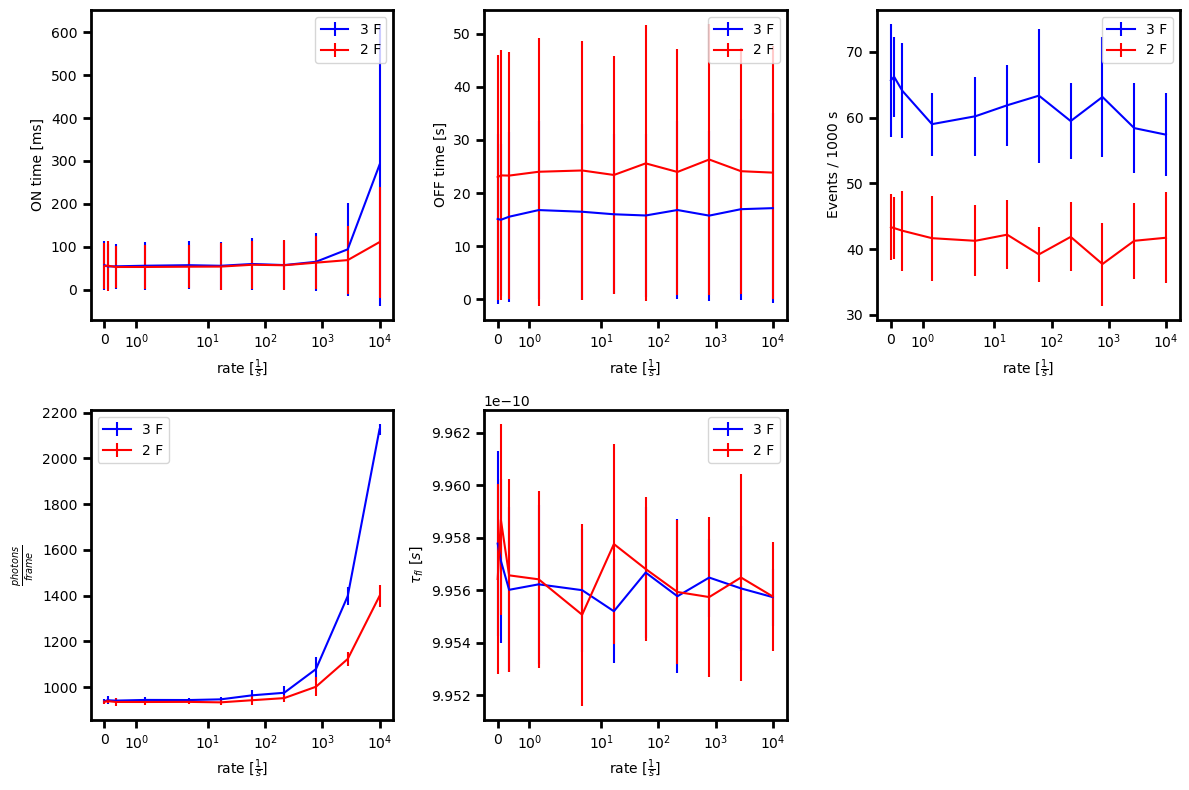

In [6]:
kwargs = {'type_': 'errorbar',
          'fontsize': 10, 
          'xlabel': r'rate [$\frac{1}{s}$]',
          'xscale': 'symlog'}

axes = fi.universal_figure(ncols=3, nrows=2, fig_height=8, fig_width=12,
                           data=[rates, on_times_mean_std[:, 0], on_times_mean_std[:, 1]], 
                           **kwargs, ylabel='ON time [ms]', label='3 F')
fi.universal_figure(data=[rates, on_times_mean_std_2[:, 0], on_times_mean_std_2[:, 1]],
                   **kwargs, ylabel='ON time [ms]', label='2 F', axes=axes[0, 0], color='r', legend=True)
fi.universal_figure(data=[rates, off_times_mean_std[:, 0], off_times_mean_std[:, 1]],
                   **kwargs, axes=axes[0, 1], ylabel='OFF time [s]', label='3 F')
fi.universal_figure(data=[rates, off_times_mean_std_2[:, 0], off_times_mean_std_2[:, 1]],
                   **kwargs, axes=axes[0, 1], ylabel='OFF time [s]', label='2 F', color='r', legend=True)
fi.universal_figure(data=[rates, on_numbers_mean_std[:, 0], on_numbers_mean_std[:, 1]],
                    **kwargs, axes=axes[0, 2], ylabel='Events / 1000 s', label='3 F')
fi.universal_figure(data=[rates, on_numbers_mean_std_2[:, 0], on_numbers_mean_std_2[:, 1]],
                    **kwargs, axes=axes[0, 2], ylabel='Events / 1000 s', label='2 F', color='r', legend=True)
fi.universal_figure(data=[rates, mean_intensities, std_intensities], 
                    **kwargs, axes=axes[1, 0], ylabel=r'$\frac{photons}{frame}$', label='3 F')
fi.universal_figure(data=[rates, mean_intensities_2, std_intensities_2], 
                    **kwargs, axes=axes[1, 0], ylabel=r'$\frac{photons}{frame}$', label='2 F', color='r', legend=True)
fi.universal_figure(data=[rates, mean_lifetimes, std_lifetimes],
                    **kwargs, axes=axes[1, 1], ylabel=r'$\tau_{fl} \ [s]$', label='3 F')
fi.universal_figure(data=[rates, mean_lifetimes_2, std_lifetimes_2],
                    **kwargs, axes=axes[1, 1], ylabel=r'$\tau_{fl} \ [s]$', label='2 F', color='r', legend=True)
mi.delete_subplots(axes=axes, keep_number=5)

axes[0, 0].get_figure().tight_layout()